In [5]:
import pandas as pd

wilderness_columns = []
soil_columns = []
other_columns = [
    "Elevation",
    "Aspect",
    "Slope",
    "Horizontal_Distance_To_Hydrology",
    "Vertical_Distance_To_Hydrology",
    "Horizontal_Distance_To_Roadways",
    "Hillshade_9am",
    "Hillshade_Noon",
    "Hillshade_3pm",
    "Horizontal_Distance_To_Fire_Points",
]



for i in range(1,5):
    wilderness_columns += [f"Wilderness_Area_{i:02d}"]

for i in range(1,41):
    soil_columns += [f"Soil_Type_{i:02d}"]

column_names = other_columns + wilderness_columns + soil_columns + ["Cover_Type"]

df = pd.read_csv("covtype.csv", header=None)

df.columns = column_names

df['Cover_Type'] = df['Cover_Type'] - 1


Información del dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 581012 entries, 0 to 581011
Data columns (total 55 columns):
 #   Column                              Non-Null Count   Dtype
---  ------                              --------------   -----
 0   Elevation                           581012 non-null  int64
 1   Aspect                              581012 non-null  int64
 2   Slope                               581012 non-null  int64
 3   Horizontal_Distance_To_Hydrology    581012 non-null  int64
 4   Vertical_Distance_To_Hydrology      581012 non-null  int64
 5   Horizontal_Distance_To_Roadways     581012 non-null  int64
 6   Hillshade_9am                       581012 non-null  int64
 7   Hillshade_Noon                      581012 non-null  int64
 8   Hillshade_3pm                       581012 non-null  int64
 9   Horizontal_Distance_To_Fire_Points  581012 non-null  int64
 10  Wilderness_Area_01                  581012 non-null  int64
 11  Wilderness_Area_02         

,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,...,Soil_Type_32,Soil_Type_33,Soil_Type_34,Soil_Type_35,Soil_Type_36,Soil_Type_37,Soil_Type_38,Soil_Type_39,Soil_Type_40,Cover_Type
count,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,...,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000
mean,2959.365301,155.656807,14.103704,269.428217,46.418855,2350.146611,212.146049,223.318716,142.528263,1980.291226,...,0.090392,0.077716,0.002773,0.003255,0.000205,0.000513,0.026803,0.023762,0.015060,1.051471
std,279.984734,111.913721,7.488242,212.549356,58.295232,1559.254870,26.769889,19.768697,38.274529,1324.195210,...,0.286743,0.267725,0.052584,0.056957,0.014310,0.022641,0.161508,0.152307,0.121791,1.396504
min,1859.000000,0.000000,0.000000,0.000000,-173.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2809.000000,58.000000,9.000000,108.000000,7.000000,1106.000000,198.000000,213.000000,119.000000,1024.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,2996.000000,127.000000,13.000000,218.000000,30.000000,1997.000000,218.000000,226.000000,143.000000,1710.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
75%,3163.000000,260.000000,18.000000,384.000000,69.000000,3328.000000,231.000000,237.000000,168.000000,2550.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
max,3858.000000,360.000000,66.000000,1397.000000,601.000000,7117.000000,254.000000,254.000000,254.000000,7173.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,6.000000


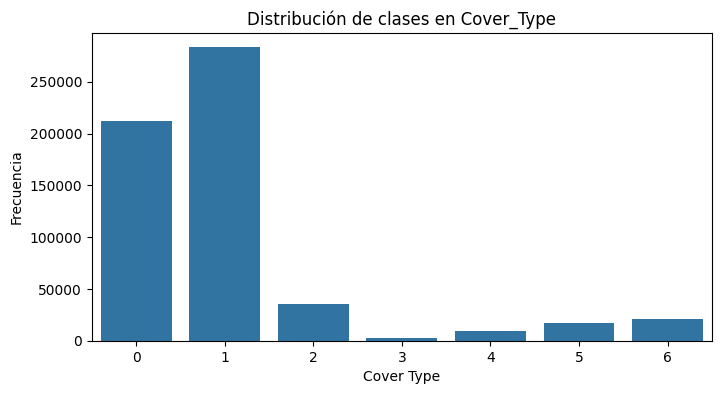

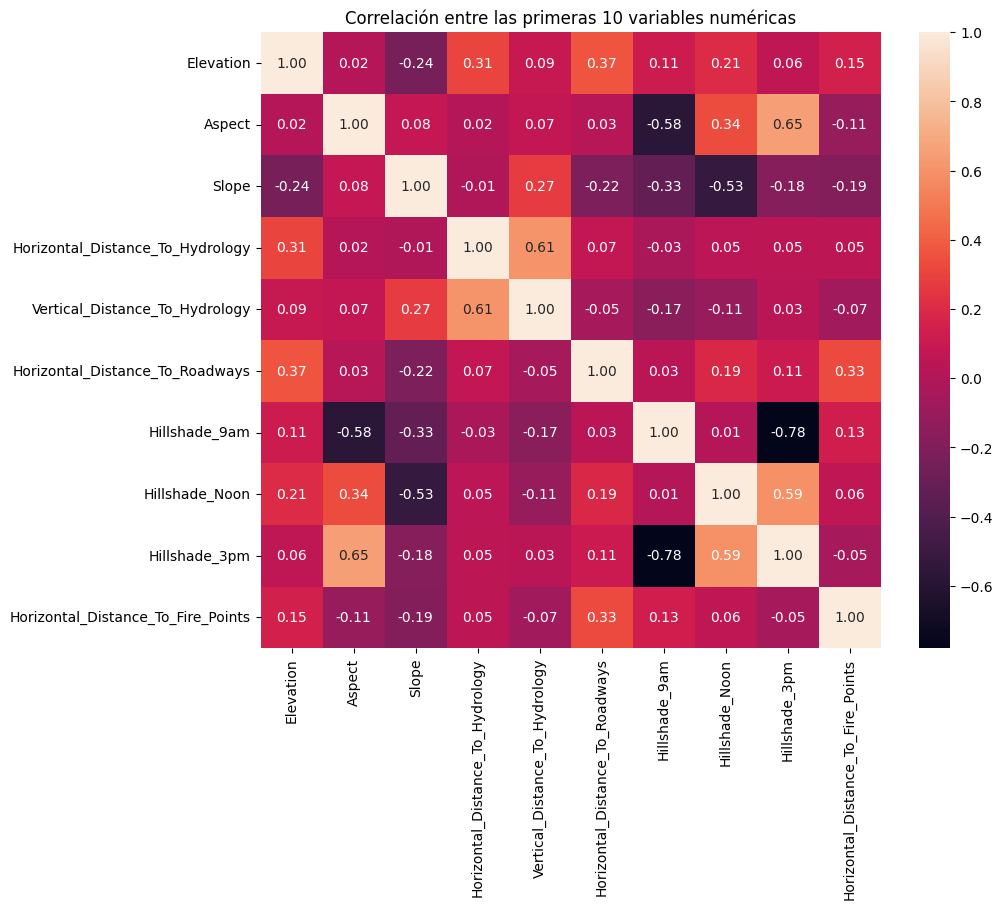

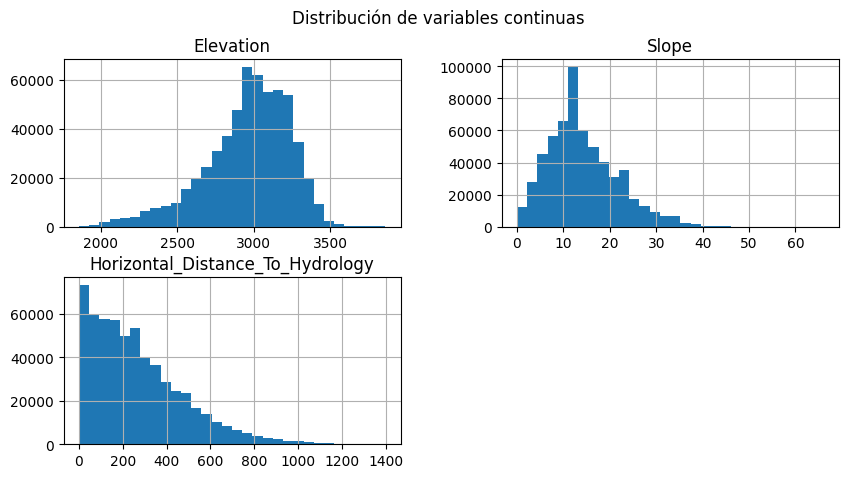

In [6]:
# ==============================================================
# Exploración y análisis inicial del dataset Covertype
# ==============================================================

import matplotlib.pyplot as plt
import seaborn as sns

#  Información general
print("Información del dataset:")
print(df.info())

# Estadísticas descriptivas
print("\n Estadísticas básicas:")
display(df.describe())

# Ver la distribución de la variable objetivo (Cover_Type)
plt.figure(figsize=(8,4))
sns.countplot(x='Cover_Type', data=df)
plt.title('Distribución de clases en Cover_Type')
plt.xlabel('Cover Type')
plt.ylabel('Frecuencia')
plt.show()

# Correlación entre variables numéricas
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True).iloc[:10, :10], annot=True, fmt=".2f")
plt.title("Correlación entre las primeras 10 variables numéricas")
plt.show()

# Ejemplo de histogramas de algunas variables
cols = ['Elevation', 'Slope', 'Horizontal_Distance_To_Hydrology']
df[cols].hist(figsize=(10, 5), bins=30)
plt.suptitle('Distribución de variables continuas')
plt.show()


 Tamaño del conjunto de entrenamiento: (406708, 54)
 Tamaño del conjunto de prueba: (174304, 54)

 Entrenando modelo...

 Precisión del modelo: 0.9506

 Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.96      0.94      0.95     63552
           1       0.95      0.97      0.96     84991
           2       0.94      0.96      0.95     10726
           3       0.90      0.84      0.87       824
           4       0.95      0.76      0.84      2848
           5       0.92      0.89      0.91      5210
           6       0.98      0.94      0.96      6153

    accuracy                           0.95    174304
   macro avg       0.94      0.90      0.92    174304
weighted avg       0.95      0.95      0.95    174304



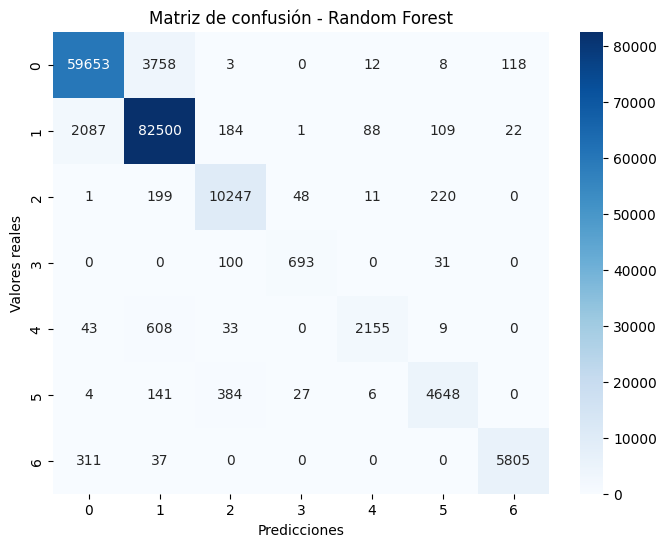

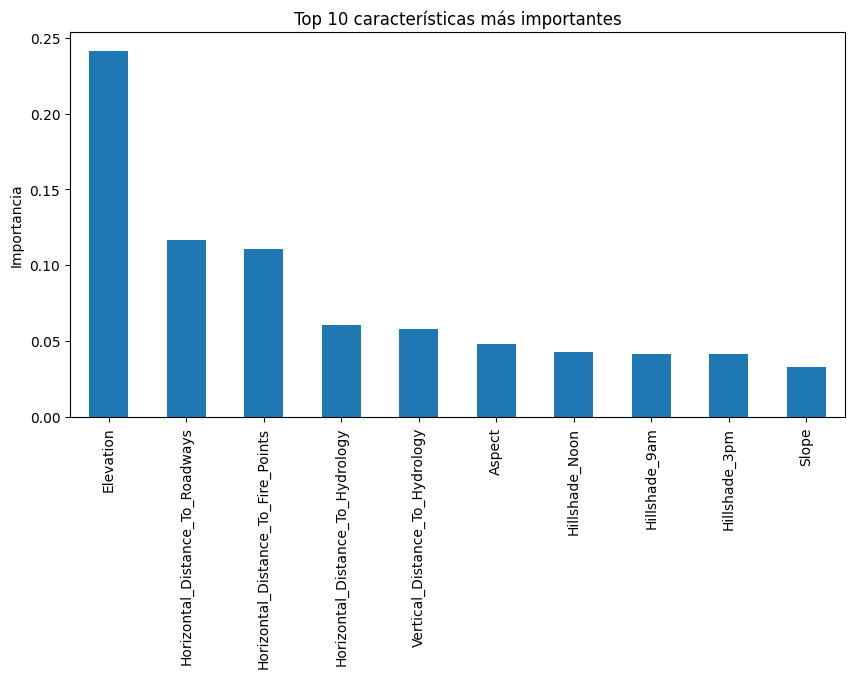

In [7]:
# ==============================================================
# Entrenamiento de Random Forest
# ==============================================================

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Separar características (X) y variable objetivo (y)
X = df.drop('Cover_Type', axis=1)
y = df['Cover_Type']

# Dividir en conjunto de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

print(f" Tamaño del conjunto de entrenamiento: {X_train.shape}")
print(f" Tamaño del conjunto de prueba: {X_test.shape}")

# Crear y entrenar el modelo Random Forest
rf = RandomForestClassifier(
    n_estimators=100,     # número de árboles
    max_depth=None,       # sin límite de profundidad
    random_state=42,
    n_jobs=-1             # usar todos los núcleos del CPU
)

print("\n Entrenando modelo...")
rf.fit(X_train, y_train)

# Evaluar el modelo
y_pred = rf.predict(X_test)

acc = accuracy_score(y_test, y_pred)
print(f"\n Precisión del modelo: {acc:.4f}")

# Reporte detallado
print("\n Reporte de clasificación:")
print(classification_report(y_test, y_pred))

# Matriz de confusión
plt.figure(figsize=(8,6))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt="d", cmap="Blues")
plt.title("Matriz de confusión - Random Forest")
plt.xlabel("Predicciones")
plt.ylabel("Valores reales")
plt.show()

# Importancia de características
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
plt.figure(figsize=(10,5))
importances.head(10).plot(kind='bar')
plt.title("Top 10 características más importantes")
plt.ylabel("Importancia")
plt.show()


In [8]:
# ==============================================================
# Optimización
# ==============================================================

from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from scipy.stats import randint
from sklearn.metrics import accuracy_score

#  Modelo base
rf = RandomForestClassifier(random_state=42, n_jobs=-1)

# Espacio reducido de búsqueda de hiperparámetros
param_dist = {
    'n_estimators': randint(50, 100),
    'max_depth': [10, 20, None],
    'min_samples_split': randint(2, 5),
    'min_samples_leaf': randint(1, 3),
    'max_features': ['sqrt', 'log2']
}

#  Configuración RandomizedSearchCV rápida
random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=5,          # solo 5 combinaciones para reducir tiempo
    cv=2,              # validación cruzada 2-fold
    verbose=2,
    random_state=42,
    n_jobs=-1
)

#  Entrenar búsqueda rápida
print("Buscando mejores hiperparámetros (rápido)...")
random_search.fit(X_train, y_train)

# Mejor modelo encontrado
best_rf = random_search.best_estimator_
print("\nMejores hiperparámetros:")
print(random_search.best_params_)

# Evaluar el modelo optimizado
y_pred_opt = best_rf.predict(X_test)
acc_opt = accuracy_score(y_test, y_pred_opt)
print(f"\nPrecisión optimizada (rápida): {acc_opt:.4f}")


Buscando mejores hiperparámetros (rápido)...
Fitting 2 folds for each of 5 candidates, totalling 10 fits
[CV] END max_depth=10, max_features=sqrt, min_samples_leaf=1, min_samples_split=3, n_estimators=68; total time=  23.1s
[CV] END max_depth=10, max_features=sqrt, min_samples_leaf=1, min_samples_split=3, n_estimators=68; total time=  24.3s
[CV] END max_depth=20, max_features=log2, min_samples_leaf=2, min_samples_split=2, n_estimators=82; total time=  31.9s
[CV] END max_depth=20, max_features=log2, min_samples_leaf=2, min_samples_split=2, n_estimators=82; total time=  33.1s
[CV] END max_depth=None, max_features=log2, min_samples_leaf=1, min_samples_split=4, n_estimators=92; total time=  39.1s
[CV] END max_depth=None, max_features=log2, min_samples_leaf=1, min_samples_split=3, n_estimators=73; total time=  37.4s
[CV] END max_depth=None, max_features=log2, min_samples_leaf=1, min_samples_split=3, n_estimators=73; total time=  38.3s
[CV] END max_depth=None, max_features=log2, min_samples_

In [9]:
# ==============================================================
# Guardar el modelo entrenado en un archivo .pkl
# ==============================================================

import joblib

joblib.dump(random_search, "random_forest_model.pkl", compress=("lzma", 9))

print(" Modelo guardado como 'random_forest_model.pkl'")

 Modelo guardado como 'random_forest_model.pkl'
